# CTRL IS HERS - ASSESMENT 1 - ML



## 1. Kitabxanalar

In [ ]:
!pip install -q catboost xgboost lightgbm shap

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder, FunctionTransformer

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (RandomForestClassifier, GradientBoostingClassifier,
                              ExtraTreesClassifier, AdaBoostClassifier)
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
import time

from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, ConfusionMatrixDisplay, RocCurveDisplay)
from sklearn.inspection import permutation_importance, PartialDependenceDisplay

import warnings
warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
RANDOM_STATE = 42

## 2. Datanı yükləyək

In [ ]:
df = pd.read_csv("/content/train.csv")
print(df.shape)
df.head()

(31715, 49)


,id,publish_date,weekday,channel,n_tokens_title,n_tokens_content,n_unique_tokens,n_non_stop_words,n_non_stop_unique_tokens,num_hrefs,...,min_positive_polarity,max_positive_polarity,avg_negative_polarity,min_negative_polarity,max_negative_polarity,title_subjectivity,title_sentiment_polarity,abs_title_subjectivity,abs_title_sentiment_polarity,target
0,0,2013-01-07,Monday,Entertainment,12.0,219.0,0.663594,1.0,0.815385,4.0,...,0.100000,0.7,-0.350000,-0.600,-0.200000,0.500000,-0.187500,0.000000,0.187500,0
1,1,2013-01-07,Monday,Business,9.0,255.0,0.604743,1.0,0.791946,3.0,...,0.033333,0.7,-0.118750,-0.125,-0.100000,0.000000,0.000000,0.500000,0.000000,0
2,2,2013-01-07,Monday,Business,9.0,211.0,0.575130,1.0,0.663866,3.0,...,0.100000,1.0,-0.466667,-0.800,-0.133333,0.000000,0.000000,0.500000,0.000000,1
3,3,2013-01-07,Monday,Entertainment,9.0,531.0,0.503788,1.0,0.665635,9.0,...,0.136364,0.8,-0.369697,-0.600,-0.166667,0.000000,0.000000,0.500000,0.000000,0
4,4,2013-01-07,Monday,Tech,13.0,1072.0,0.415646,1.0,0.540890,19.0,...,0.033333,1.0,-0.220192,-0.500,-0.050000,0.454545,0.136364,0.045455,0.136364,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31715 entries, 0 to 31714
Data columns (total 49 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   id                            31715 non-null  int64  
 1   publish_date                  31715 non-null  object 
 2   weekday                       31715 non-null  object 
 3   channel                       31715 non-null  object 
 4   n_tokens_title                31715 non-null  float64
 5   n_tokens_content              31715 non-null  float64
 6   n_unique_tokens               31715 non-null  float64
 7   n_non_stop_words              31715 non-null  float64
 8   n_non_stop_unique_tokens      31715 non-null  float64
 9   num_hrefs                     31715 non-null  float64
 10  num_self_hrefs                31715 non-null  float64
 11  num_imgs                      31715 non-null  float64
 12  num_videos                    31715 non-null  float64
 13  a

In [ ]:
pd.DataFrame({
    "boşluq %": (df.isnull().mean() * 100).round(1),
    "unikal":   df.nunique(),
    "nümunə":   [df[c].dropna().unique()[:5] for c in df.columns],
})

,boşluq %,unikal,nümunə
id,0.0,31715,"[0, 1, 2, 3, 4]"
publish_date,0.0,599,"[2013-01-07, 2013-01-08, 2013-01-09, 2013-01-1..."
weekday,0.0,7,"[Monday, Tuesday, Wednesday, Thursday, Friday]"
channel,0.0,7,"[Entertainment, Business, Tech, Lifestyle, World]"
n_tokens_title,0.0,18,"[12.0, 9.0, 13.0, 10.0, 8.0]"
n_tokens_content,0.0,2304,"[219.0, 255.0, 211.0, 531.0, 1072.0]"
n_unique_tokens,0.0,23079,"[0.663594466988, 0.604743080614, 0.57512953069..."
n_non_stop_words,0.0,1419,"[0.999999992308, 0.999999993289, 0.99999999159..."
n_non_stop_unique_tokens,0.0,19693,"[0.815384609112, 0.79194630341, 0.66386554064,..."
num_hrefs,0.0,129,"[4.0, 3.0, 9.0, 19.0, 2.0]"


## 3. Əvvəlcə bölürük: train / test

In [ ]:
df = df.drop(columns=["id","publish_date"])
X = df.drop(columns="target")
y = df["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
print("Train:", X_train.shape, " Test:", X_test.shape)
print("train:", round(y_train.mean(), 3), " test:", round(y_test.mean(), 3))

Train: (25372, 46)  Test: (6343, 46)
train: 0.547  test: 0.547


In [ ]:
X.head()

,weekday,channel,n_tokens_title,n_tokens_content,n_unique_tokens,n_non_stop_words,n_non_stop_unique_tokens,num_hrefs,num_self_hrefs,num_imgs,...,avg_positive_polarity,min_positive_polarity,max_positive_polarity,avg_negative_polarity,min_negative_polarity,max_negative_polarity,title_subjectivity,title_sentiment_polarity,abs_title_subjectivity,abs_title_sentiment_polarity
0,Monday,Entertainment,12.0,219.0,0.663594,1.0,0.815385,4.0,2.0,1.0,...,0.378636,0.100000,0.7,-0.350000,-0.600,-0.200000,0.500000,-0.187500,0.000000,0.187500
1,Monday,Business,9.0,255.0,0.604743,1.0,0.791946,3.0,1.0,1.0,...,0.286915,0.033333,0.7,-0.118750,-0.125,-0.100000,0.000000,0.000000,0.500000,0.000000
2,Monday,Business,9.0,211.0,0.575130,1.0,0.663866,3.0,1.0,1.0,...,0.495833,0.100000,1.0,-0.466667,-0.800,-0.133333,0.000000,0.000000,0.500000,0.000000
3,Monday,Entertainment,9.0,531.0,0.503788,1.0,0.665635,9.0,0.0,1.0,...,0.385965,0.136364,0.8,-0.369697,-0.600,-0.166667,0.000000,0.000000,0.500000,0.000000
4,Monday,Tech,13.0,1072.0,0.415646,1.0,0.540890,19.0,19.0,20.0,...,0.411127,0.033333,1.0,-0.220192,-0.500,-0.050000,0.454545,0.136364,0.045455,0.136364


## 4. EDA — yalnız train datası üzərində

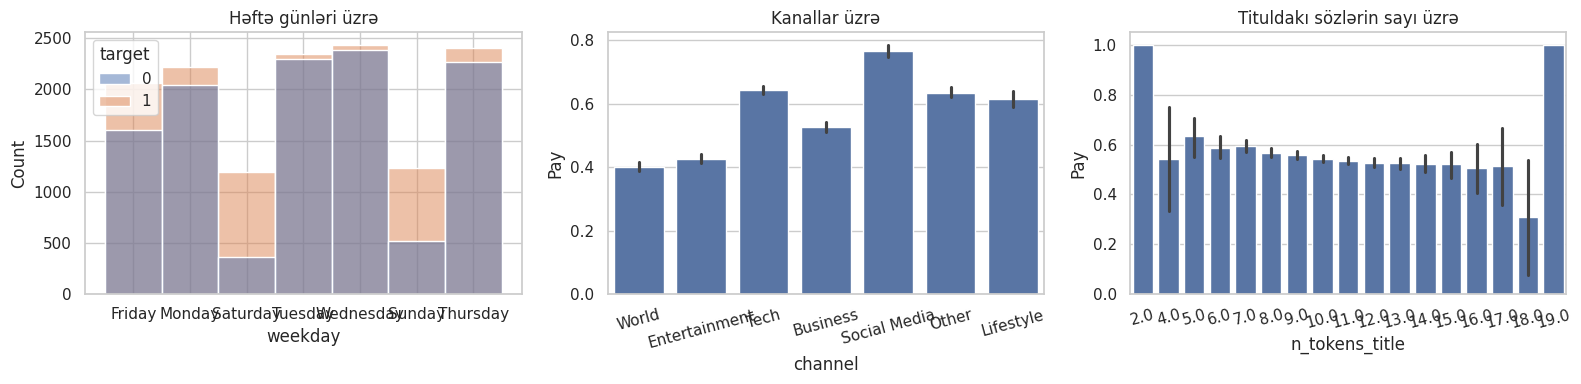

In [ ]:
eda = X_train.assign(target=y_train)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
sns.histplot(data=eda, x="weekday", hue="target", bins=30, ax=axes[0]).set_title("Həftə günləri üzrə")
sns.barplot(data=eda, x="channel", y="target", ax=axes[1]).set_title("Kanallar üzrə")
sns.barplot(data=eda, x="n_tokens_title", y="target", ax=axes[2]).set_title("Tituldakı sözlərin sayı üzrə")
for ax in axes[1:]:
    ax.set_ylabel("Pay")
    ax.tick_params(axis="x", rotation=15)
plt.tight_layout()
plt.show()

## 5. Preprocessing

In [ ]:
df.select_dtypes(exclude=['object'])

,n_tokens_title,n_tokens_content,n_unique_tokens,n_non_stop_words,n_non_stop_unique_tokens,num_hrefs,num_self_hrefs,num_imgs,num_videos,average_token_length,...,min_positive_polarity,max_positive_polarity,avg_negative_polarity,min_negative_polarity,max_negative_polarity,title_subjectivity,title_sentiment_polarity,abs_title_subjectivity,abs_title_sentiment_polarity,target
0,12.0,219.0,0.663594,1.0,0.815385,4.0,2.0,1.0,0.0,4.680365,...,0.100000,0.7,-0.350000,-0.600,-0.200000,0.500000,-0.187500,0.000000,0.187500,0
1,9.0,255.0,0.604743,1.0,0.791946,3.0,1.0,1.0,0.0,4.913725,...,0.033333,0.7,-0.118750,-0.125,-0.100000,0.000000,0.000000,0.500000,0.000000,0
2,9.0,211.0,0.575130,1.0,0.663866,3.0,1.0,1.0,0.0,4.393365,...,0.100000,1.0,-0.466667,-0.800,-0.133333,0.000000,0.000000,0.500000,0.000000,1
3,9.0,531.0,0.503788,1.0,0.665635,9.0,0.0,1.0,0.0,4.404896,...,0.136364,0.8,-0.369697,-0.600,-0.166667,0.000000,0.000000,0.500000,0.000000,0
4,13.0,1072.0,0.415646,1.0,0.540890,19.0,19.0,20.0,0.0,4.682836,...,0.033333,1.0,-0.220192,-0.500,-0.050000,0.454545,0.136364,0.045455,0.136364,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
31710,11.0,167.0,0.568493,1.0,0.575472,23.0,2.0,20.0,0.0,4.718563,...,0.100000,0.8,-0.281731,-0.500,-0.050000,0.650000,0.350000,0.150000,0.350000,1
31711,12.0,795.0,0.465736,1.0,0.623246,23.0,15.0,2.0,1.0,4.826415,...,0.062500,0.9,-0.223264,-0.400,-0.050000,0.000000,0.000000,0.500000,0.000000,1
31712,13.0,1018.0,0.453823,1.0,0.631491,10.0,5.0,2.0,0.0,4.513752,...,0.050000,0.9,-0.239074,-0.600,-0.050000,0.100000,0.000000,0.400000,0.000000,1
31713,10.0,190.0,0.609626,1.0,0.774775,2.0,1.0,1.0,1.0,4.357895,...,0.100000,1.0,-1.000000,-1.000,-1.000000,0.000000,0.000000,0.500000,0.000000,1


In [ ]:
import numpy as np
from sklearn.preprocessing import FunctionTransformer

# 1. Mətni olmayan sətirləri (n_tokens_content == 0) Train setindən silirik
train_idx = X_train[X_train['n_tokens_content'] > 0].index
X_train = X_train.loc[train_idx]
y_train = y_train.loc[train_idx]

# 2. Pipeline daxilində log transform ediləcək və edilməyəcək sütunları müəyyən edirik
skewed_cols = ['num_hrefs', 'num_self_hrefs', 'num_imgs', 'num_videos', 'kw_avg_avg']
num_cols = df.select_dtypes(exclude=['object']).columns.drop('target', errors='ignore').tolist()
# Digər rəqəmsal sütunlar (log tətbiq edilməyənlər)
normal_num_cols = [c for c in num_cols if c not in skewed_cols]
nom_cols = ["weekday", "channel"]

# Log transform preprocessor-ı
log_transformer = Pipeline([
    ("impute", SimpleImputer(strategy="median")),
    ("log1p", FunctionTransformer(np.log1p, validate=False)),
    ("scale", StandardScaler())
])

# Standart rəqəmsal preprocessor
standard_numeric = Pipeline([
    ("impute", SimpleImputer(strategy="median")),
    ("scale",  StandardScaler())
])

# Kateqoriyal preprocessor
nominal = Pipeline([
    ("impute", SimpleImputer(strategy="constant", fill_value="Unknown")),
    ("encode", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
])

# ColumnTransformer-ə əlavə edirik
preprocess = Pipeline([
    ("columns", ColumnTransformer([
        ("skewed", log_transformer, skewed_cols),
        ("num",  standard_numeric, normal_num_cols),
        ("nom",  nominal, nom_cols),
    ], remainder="passthrough", verbose_feature_names_out=False)),
])
preprocess.set_output(transform="pandas")

# Transformasiyanı yoxlayırıq
Xt_train = preprocess.fit_transform(X_train)
Xt_test  = preprocess.transform(X_test)
print("Preprocess-dən sonra:", Xt_train.shape, Xt_test.shape)
print("Boşluq qaldı?", Xt_train.isnull().sum().sum(), Xt_test.isnull().sum().sum())
Xt_train.head()

Preprocess-dən sonra: (25006, 58) (6343, 58)
Boşluq qaldı? 0 0


,num_hrefs,num_self_hrefs,num_imgs,num_videos,kw_avg_avg,n_tokens_title,n_tokens_content,n_unique_tokens,n_non_stop_words,n_non_stop_unique_tokens,...,weekday_Thursday,weekday_Tuesday,weekday_Wednesday,channel_Business,channel_Entertainment,channel_Lifestyle,channel_Other,channel_Social Media,channel_Tech,channel_World
14400,0.095144,-1.846246,-0.435730,-0.562657,-0.645128,-0.587604,0.194458,-0.298301,0.576569,0.054097,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
6417,0.462189,0.783285,-0.435730,-0.562657,0.199411,0.380483,-0.354304,0.420267,0.309903,0.142783,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
14811,0.662386,-1.846246,-0.435730,-0.562657,1.168735,0.380483,0.382303,-0.084948,0.668309,0.583270,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
16176,1.064851,1.672831,1.283027,0.442864,0.009567,0.864526,3.406824,-1.778298,1.026953,-1.448246,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
9969,-0.874564,0.188237,-1.134572,-0.562657,-0.271288,1.832613,-0.964273,2.113026,-2.744155,1.992160,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0


## 6. Modelləri quraq

In [ ]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "kNN (k=15)":          KNeighborsClassifier(n_neighbors=15),
    "SVM":                 SVC(probability=True, random_state=RANDOM_STATE),
    "Decision Tree":       DecisionTreeClassifier(random_state=RANDOM_STATE),
    "Random Forest":       RandomForestClassifier(n_estimators=200, n_jobs=-1, random_state=RANDOM_STATE),
    "Gradient Boosting":   GradientBoostingClassifier(random_state=RANDOM_STATE),
    # Müasir boosting kitabxanaları
    "XGBoost":  XGBClassifier(n_estimators=300, learning_rate=0.05, max_depth=4,
                              subsample=0.8, colsample_bytree=0.8, random_state=RANDOM_STATE, n_jobs=-1),
    "LightGBM": LGBMClassifier(n_estimators=300, learning_rate=0.03, num_leaves=15, min_child_samples=40,
                               subsample=0.8, subsample_freq=1, colsample_bytree=0.8,
                               random_state=RANDOM_STATE, verbose=-1),
    "CatBoost": CatBoostClassifier(iterations=500, learning_rate=0.05, depth=6,
                                   random_seed=RANDOM_STATE, verbose=0),
}

pipelines = {name: Pipeline([("prep", preprocess), ("model", m)]) for name, m in models.items()}

## 7. Öyrədək və müqayisə edək

In [ ]:
results = []
for name, pipe in pipelines.items():
    start = time.time()
    pipe.fit(X_train, y_train)
    fit_time = time.time() - start
    y_pred  = pipe.predict(X_test)
    y_proba = pipe.predict_proba(X_test)[:, 1]
    results.append({
        "Model":          name,
        "Train Accuracy": accuracy_score(y_train, pipe.predict(X_train)),
        "Accuracy":       accuracy_score(y_test, y_pred),
        "Precision":      precision_score(y_test, y_pred),
        "Recall":         recall_score(y_test, y_pred),
        "F1":             f1_score(y_test, y_pred),
        "ROC-AUC":        roc_auc_score(y_test, y_proba),
        "Vaxt (s)":       fit_time,
    })
    print(f"✓ {name:<20} {fit_time:.1f} s")

results_df = pd.DataFrame(results).set_index("Model").sort_values("ROC-AUC", ascending=False)
results_df.round(3)

✓ Logistic Regression  0.4 s
✓ kNN (k=15)           0.2 s
✓ SVM                  253.3 s
✓ Decision Tree        1.8 s
✓ Random Forest        23.2 s
✓ Gradient Boosting    30.4 s
✓ XGBoost              2.5 s
✓ LightGBM             2.0 s
✓ CatBoost             9.0 s


,Train Accuracy,Accuracy,Precision,Recall,F1,ROC-AUC,Vaxt (s)
Model,,,,,,,
XGBoost,0.722,0.670,0.686,0.733,0.708,0.730,2.533
LightGBM,0.710,0.667,0.683,0.733,0.707,0.730,1.989
CatBoost,0.756,0.670,0.687,0.731,0.708,0.728,8.964
Gradient Boosting,0.689,0.666,0.682,0.729,0.705,0.723,30.416
Random Forest,1.000,0.662,0.675,0.735,0.704,0.715,23.245
SVM,0.730,0.656,0.671,0.729,0.699,0.712,253.342
Logistic Regression,0.653,0.642,0.658,0.720,0.688,0.689,0.421
kNN (k=15),0.676,0.618,0.651,0.654,0.652,0.652,0.204
Decision Tree,1.000,0.581,0.618,0.614,0.616,0.577,1.847


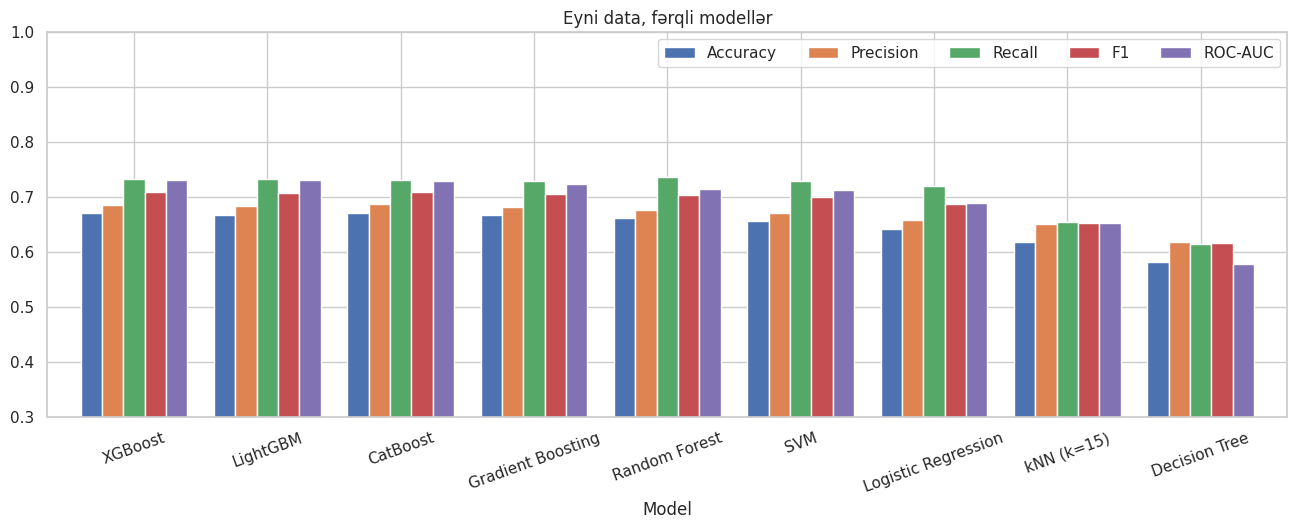

In [ ]:
results_df[["Accuracy", "Precision", "Recall", "F1", "ROC-AUC"]].plot(
    kind="bar", figsize=(16, 5), ylim=(0.3, 1.0), width=0.8)
plt.title("Eyni data, fərqli modellər")
plt.xticks(rotation=20)
plt.legend(loc="upper right", ncol=5)
plt.show()

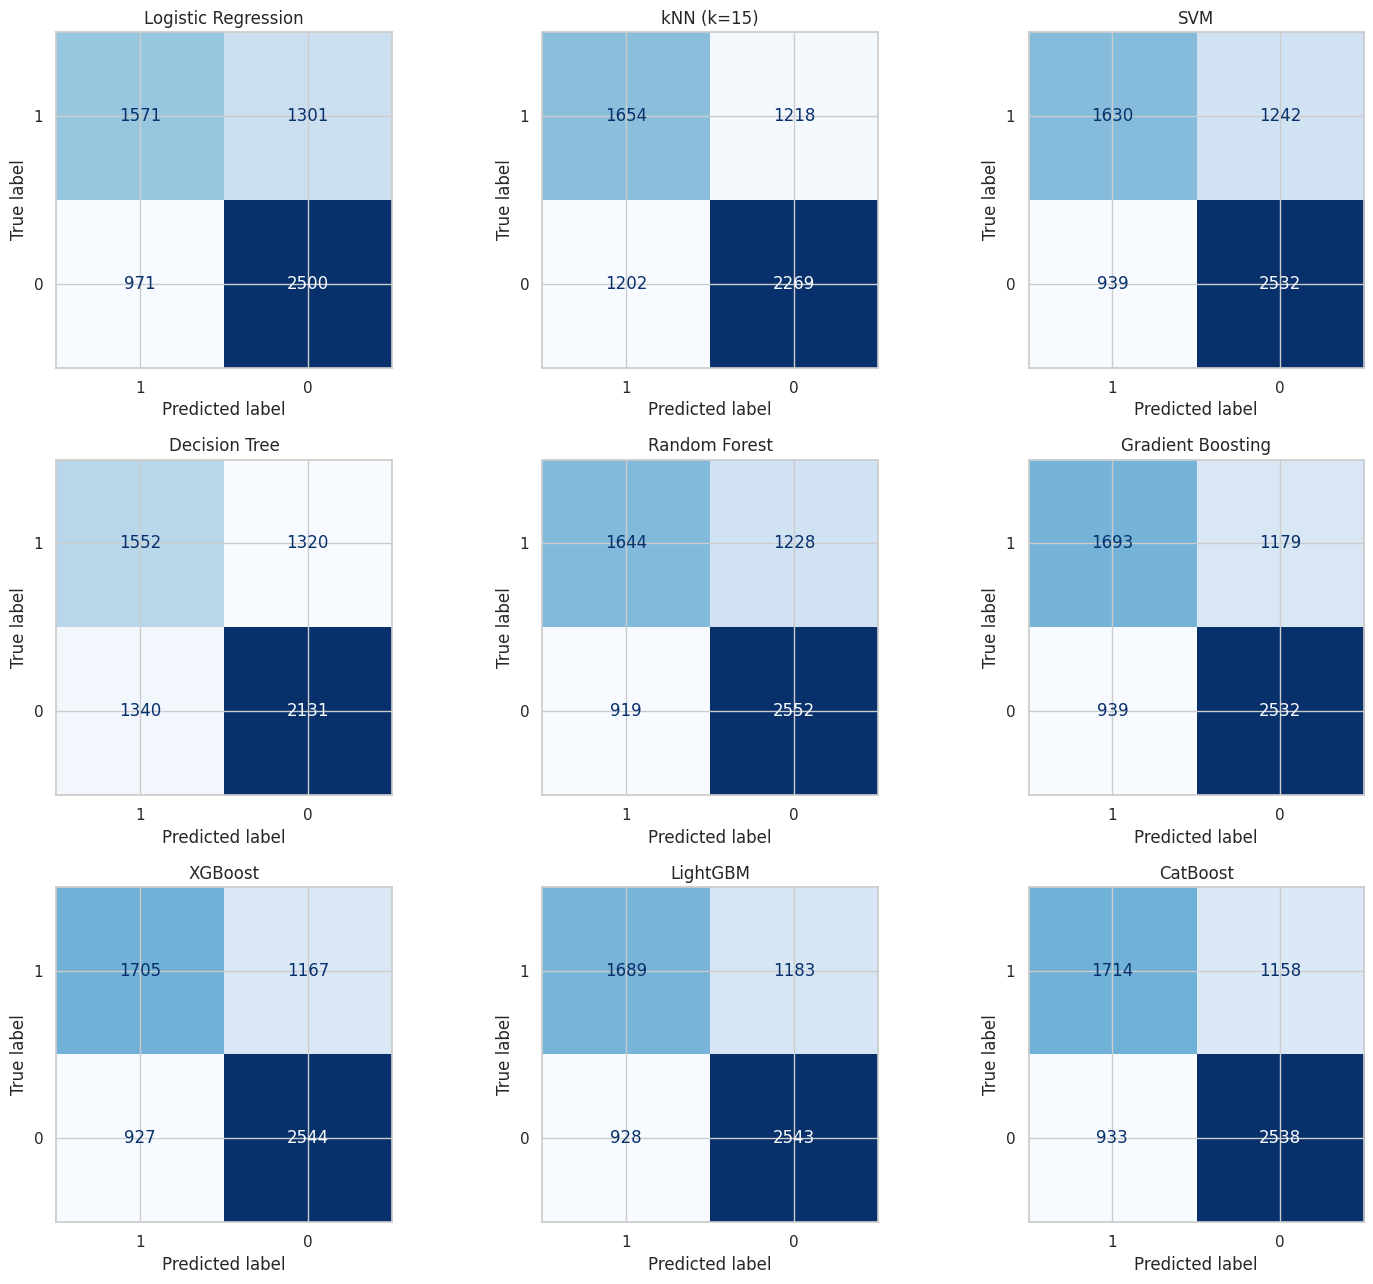

In [ ]:
fig, axes = plt.subplots(3, 3, figsize=(15, 13))
for ax, (name, pipe) in zip(axes.ravel(), pipelines.items()):
    ConfusionMatrixDisplay.from_estimator(pipe, X_test, y_test, ax=ax, colorbar=False,
                                          display_labels=["1", "0"], cmap="Blues")
    ax.set_title(name)
plt.tight_layout()
plt.show()

In [ ]:
df_test= pd.read_csv("test.csv")

In [ ]:
df_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7929 entries, 0 to 7928
Data columns (total 48 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   id                            7929 non-null   int64  
 1   publish_date                  7929 non-null   object 
 2   weekday                       7929 non-null   object 
 3   channel                       7929 non-null   object 
 4   n_tokens_title                7929 non-null   float64
 5   n_tokens_content              7929 non-null   float64
 6   n_unique_tokens               7929 non-null   float64
 7   n_non_stop_words              7929 non-null   float64
 8   n_non_stop_unique_tokens      7929 non-null   float64
 9   num_hrefs                     7929 non-null   float64
 10  num_self_hrefs                7929 non-null   float64
 11  num_imgs                      7929 non-null   float64
 12  num_videos                    7929 non-null   float64
 13  ave

In [ ]:
X_submission= df_test.drop(columns=["id", "publish_date"], errors="ignore")

In [ ]:
best_model_name = "CatBoost"
best_pipeline = pipelines[best_model_name]

df_test["predicted_probability"] = best_pipeline.predict_proba(X_submission)[:, 1]
df_test["predicted_target"] = best_pipeline.predict(X_submission)
submission = df_test[["id", "predicted_probability"]]
display(submission.head())

submission.to_csv("submission.csv", index=False)

,id,predicted_probability
0,31715,0.744525
1,31716,0.401461
2,31717,0.733396
3,31718,0.297557
4,31719,0.257359
